# Notebook 4 : Machine Learning Model Training

## EmotionSense AI

Training machine learning models for speech emotion recognition using extracted audio features.

## Objectives

- Extract features from every audio file
- Build feature dataset
- Encode emotion labels
- Train multiple ML models
- Compare performances
- Save best model

In [1]:
import os
import numpy as np
import pandas as pd
import librosa

from tqdm import tqdm

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import LogisticRegression

import joblib

In [2]:
dataset_path = "../datasets/RAVDESS"

print(dataset_path)

../datasets/RAVDESS


In [3]:
emotion_dict = {
    "01":"Neutral",
    "02":"Calm",
    "03":"Happy",
    "04":"Sad",
    "05":"Angry",
    "06":"Fearful",
    "07":"Disgust",
    "08":"Surprised"
}

In [5]:
def extract_features(file_path):

    signal, sample_rate = librosa.load(file_path, sr=None)

    mfcc = librosa.feature.mfcc(y=signal, sr=sample_rate, n_mfcc=13)
    mfcc = np.mean(mfcc.T, axis=0)

    chroma = librosa.feature.chroma_stft(y=signal, sr=sample_rate)
    chroma = np.mean(chroma.T, axis=0)

    mel = librosa.feature.melspectrogram(y=signal, sr=sample_rate)
    mel = np.mean(mel.T, axis=0)

    zcr = librosa.feature.zero_crossing_rate(signal)
    zcr = np.mean(zcr.T, axis=0)

    rms = librosa.feature.rms(y=signal)
    rms = np.mean(rms.T, axis=0)

    centroid = librosa.feature.spectral_centroid(
        y=signal,
        sr=sample_rate
    )
    centroid = np.mean(centroid.T, axis=0)

    features = np.hstack([
        mfcc,
        chroma,
        mel,
        zcr,
        rms,
        centroid
    ])

    return features

In [6]:
sample_file = os.path.join(
    dataset_path,
    "Actor_01",
    "03-01-01-01-01-01-01.wav"
)

print(sample_file)

../datasets/RAVDESS\Actor_01\03-01-01-01-01-01-01.wav


In [7]:
features = extract_features(sample_file)

print(features)

[-7.26217224e+02  6.85414200e+01  3.29339767e+00  1.22053003e+01
  5.51027775e+00  1.36674080e+01 -2.98382831e+00  3.09802914e+00
 -3.31081343e+00 -1.56438410e+00 -7.86165237e+00 -2.12428164e+00
  2.84920406e+00  6.61943913e-01  6.53476596e-01  6.18591785e-01
  6.13644302e-01  6.28838837e-01  6.17626846e-01  6.30299687e-01
  6.41173601e-01  6.43986106e-01  6.23945475e-01  6.33899570e-01
  6.29671991e-01  1.70184157e-05  1.43234653e-03  1.66232847e-02
  2.62569897e-02  1.57336369e-02  1.05670653e-02  2.14492250e-02
  2.17550285e-02  2.05241740e-02  9.86292306e-03  8.22031125e-03
  1.38155846e-02  3.34110372e-02  4.01227549e-02  1.25717428e-02
  1.35526322e-02  3.40261199e-02  1.37796523e-02  2.77529773e-03
  9.25028231e-03  1.48122292e-02  5.43776527e-03  9.91153065e-04
  7.88527075e-04  4.98540059e-04  2.36146880e-04  2.03896241e-04
  4.22207202e-04  8.26913107e-04  6.62424893e-04  4.39797383e-04
  3.11295822e-04  1.14664016e-03  1.43222150e-03  1.61550543e-03
  3.58627876e-03  3.50482

In [8]:
print("Total Features :", len(features))

Total Features : 156


In [9]:
X = []
y = []

In [10]:
for actor in sorted(os.listdir(dataset_path)):

    actor_path = os.path.join(dataset_path, actor)

    if not os.path.isdir(actor_path):
        continue

    for file in os.listdir(actor_path):

        if not file.endswith(".wav"):
            continue

        file_path = os.path.join(actor_path, file)

        emotion_code = file.split("-")[2]

        emotion = emotion_dict[emotion_code]

        features = extract_features(file_path)

        X.append(features)

        y.append(emotion)

In [11]:
X = np.array(X)
y = np.array(y)

In [12]:
print("Feature Matrix Shape :", X.shape)

print("Labels Shape :", y.shape)

Feature Matrix Shape : (1440, 156)
Labels Shape : (1440,)


In [13]:
pd.Series(y).value_counts().sort_index()

Angry        192
Calm         192
Disgust      192
Fearful      192
Happy        192
Neutral       96
Sad          192
Surprised    192
Name: count, dtype: int64

In [14]:
feature_df = pd.DataFrame(X)

feature_df["Emotion"] = y

feature_df.head()

,0,1,2,3,4,5,6,7,8,9,...,147,148,149,150,151,152,153,154,155,Emotion
0,-726.217224,68.541420,3.293398,12.205300,5.510278,13.667408,-2.983828,3.098029,-3.310813,-1.564384,...,4.124777e-08,2.838040e-08,2.313613e-08,1.160461e-08,5.817648e-09,5.361052e-09,0.050476,0.002120,7416.297748,Neutral
1,-719.128296,70.201569,1.168397,13.122541,7.836950,14.411290,-4.111360,4.468973,-3.539367,-3.658607,...,5.679201e-08,4.239203e-08,2.718321e-08,2.001875e-08,6.524588e-09,5.564329e-09,0.052904,0.002258,7135.571471,Neutral
2,-714.995728,69.689346,3.924564,11.924190,6.421723,11.011614,-2.878103,4.509558,-4.476109,-2.671549,...,2.857482e-07,3.092056e-07,3.254221e-07,1.852740e-07,2.746004e-08,5.536617e-09,0.046627,0.002707,7239.265648,Neutral
3,-710.975281,67.564880,5.782241,13.230726,6.190845,12.628252,-1.675169,5.657494,-4.950634,-3.477545,...,5.594725e-07,2.913224e-07,1.172284e-07,4.113968e-08,7.309259e-09,5.700877e-09,0.053835,0.002521,7008.958169,Neutral
4,-759.921753,75.783524,6.023605,14.557394,6.454187,14.631508,-3.004551,4.620970,-5.200016,-0.707430,...,3.130156e-08,1.891350e-08,1.092557e-08,6.905552e-09,5.926896e-09,5.486473e-09,0.045929,0.001579,6997.311810,Calm


In [15]:
feature_df.to_csv(
    "../outputs/features_dataset.csv",
    index=False
)

print("Feature dataset saved successfully.")

Feature dataset saved successfully.


In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

import joblib

In [17]:
feature_df = pd.read_csv("../outputs/features_dataset.csv")

feature_df.head()

,0,1,2,3,4,5,6,7,8,9,...,147,148,149,150,151,152,153,154,155,Emotion
0,-726.217224,68.541420,3.293398,12.205300,5.510278,13.667408,-2.983828,3.098029,-3.310813,-1.564384,...,4.124777e-08,2.838040e-08,2.313613e-08,1.160461e-08,5.817648e-09,5.361052e-09,0.050476,0.002120,7416.297748,Neutral
1,-719.128296,70.201569,1.168397,13.122541,7.836950,14.411290,-4.111360,4.468973,-3.539367,-3.658607,...,5.679201e-08,4.239203e-08,2.718321e-08,2.001875e-08,6.524588e-09,5.564329e-09,0.052904,0.002258,7135.571471,Neutral
2,-714.995728,69.689346,3.924564,11.924190,6.421723,11.011614,-2.878103,4.509558,-4.476109,-2.671549,...,2.857482e-07,3.092056e-07,3.254221e-07,1.852740e-07,2.746004e-08,5.536617e-09,0.046627,0.002707,7239.265648,Neutral
3,-710.975281,67.564880,5.782241,13.230726,6.190845,12.628252,-1.675169,5.657494,-4.950634,-3.477545,...,5.594725e-07,2.913224e-07,1.172284e-07,4.113968e-08,7.309259e-09,5.700877e-09,0.053835,0.002521,7008.958169,Neutral
4,-759.921753,75.783524,6.023605,14.557394,6.454187,14.631508,-3.004551,4.620970,-5.200016,-0.707430,...,3.130156e-08,1.891350e-08,1.092557e-08,6.905552e-09,5.926896e-09,5.486473e-09,0.045929,0.001579,6997.311810,Calm


In [18]:
print("Dataset Shape :", feature_df.shape)

Dataset Shape : (1440, 157)


In [19]:
X = feature_df.drop("Emotion", axis=1)

y = feature_df["Emotion"]

print("Features :", X.shape)
print("Labels :", y.shape)

Features : (1440, 156)
Labels : (1440,)


In [20]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['Angry' 'Calm' 'Disgust' 'Fearful' 'Happy' 'Neutral' 'Sad' 'Surprised']


In [21]:
joblib.dump(label_encoder, "../models/label_encoder.pkl")

print("Label Encoder Saved!")

Label Encoder Saved!


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training :", X_train.shape)
print("Testing :", X_test.shape)

Training : (1152, 156)
Testing : (288, 156)


In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler Saved!")

Scaler Saved!


In [24]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (1152, 156)
Testing Features : (288, 156)
Training Labels : (1152,)
Testing Labels : (288,)


In [25]:
results = {}

In [26]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

results["Logistic Regression"] = lr_acc

print("Logistic Regression Accuracy :", lr_acc)

Logistic Regression Accuracy : 0.4375


In [27]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

results["KNN"] = knn_acc

print("KNN Accuracy :", knn_acc)

KNN Accuracy : 0.4756944444444444


In [28]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

results["Random Forest"] = rf_acc

print("Random Forest Accuracy :", rf_acc)

Random Forest Accuracy : 0.5451388888888888


In [29]:
svm = SVC(
    kernel="rbf",
    random_state=42
)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

results["SVM"] = svm_acc

print("SVM Accuracy :", svm_acc)

SVM Accuracy : 0.3784722222222222


In [30]:
results_df = pd.DataFrame(
    results.items(),
    columns=["Model", "Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
2,Random Forest,0.545139
1,KNN,0.475694
0,Logistic Regression,0.437500
3,SVM,0.378472


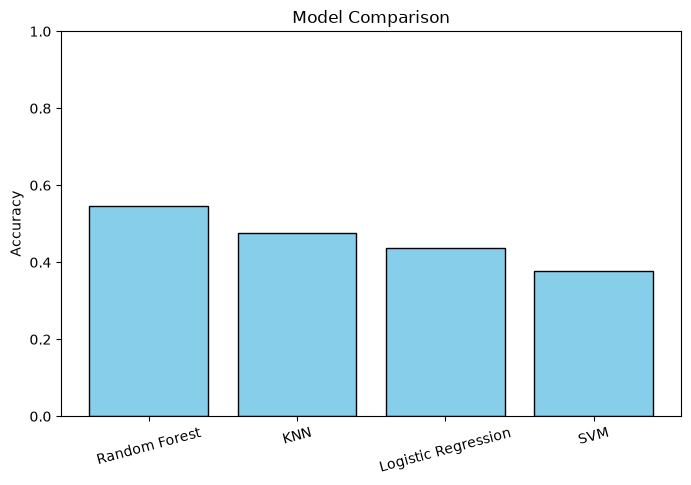

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"],
    color="skyblue",
    edgecolor="black"
)

plt.ylim(0, 1)

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.xticks(rotation=15)

plt.show()

In [32]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Random Forest


In [33]:
if best_model_name == "Logistic Regression":
    best_model = lr

elif best_model_name == "KNN":
    best_model = knn

elif best_model_name == "Random Forest":
    best_model = rf

else:
    best_model = svm

joblib.dump(best_model, "../models/best_emotion_model.pkl")

print("Best Model Saved!")

Best Model Saved!


In [34]:
results_df.to_csv(
    "../outputs/model_results.csv",
    index=False
)

print("Results Saved!")

Results Saved!
